In [23]:
import warnings

# Instalasi library yang diperlukan (-q untuk mode quiet agar output rapi)
!pip install pandas mlxtend openpyxl -q
!pip install streamlit seaborn matplotlib pandas mlxtend openpyxl -q

print("✅ Library berhasil diinstal!")
warnings.filterwarnings("ignore")



✅ Library berhasil diinstal!


# PENGEMBANGAN DECISION SUPPORT SYSTEM BERBASIS ALGORITMA APRIORI 
## UNTUK ANALISIS POLA PEMINATAN MAHASISWA

### 📋 BAB 1: BUSINESS UNDERSTANDING (PEMAHAMAN BISNIS)

#### 1.1 Latar Belakang Masalah
Program Studi dalam mengelola kurikulum menghadapi tantangan dalam memahami pola pemilihan mata kuliah mahasiswa...

#### 1.2 Tujuan Bisnis
1. **Untuk Mahasiswa**: Memberikan rekomendasi mata kuliah yang saling melengkapi
2. **Untuk Program Studi**: Memahami pola peminatan untuk perencanaan kurikulum
3. **Untuk Dosen Wali**: Memiliki dasar data dalam memberikan konsultasi akademik

#### 1.3 Stakeholder yang Diuntungkan
| Stakeholder | Manfaat |
|-------------|---------|
| Mahasiswa Baru | Mendapat rekomendasi MK yang tepat |
| Dosen Wali | Dasar data untuk konsultasi |
| Kaprodi | Insight untuk perencanaan kurikulum |

#### 1.4 Kriteria Kesuksesan (Success Criteria)
- ✅ Menemukan minimal 10 aturan asosiasi dengan Lift > 1.2
- ✅ Confidence rekomendasi minimal 60%
- ✅ Sistem dapat memberikan rekomendasi dalam waktu < 1 detik

#### 1.5 Metodologi: CRISP-DM
Proyek ini menggunakan **CRISP-DM** yang terdiri dari 6 tahap:
1. Business Understanding
2. Data Understanding  
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

In [24]:
import pandas as pd

print("[TAHAP 1 & 2] Business & Data Understanding")

try:
    # 1. Baca file TANPA header terlebih dahulu untuk memindai isi file
    df_raw = pd.read_excel('data_mahasiswa.xlsx', sheet_name='Data Mahasiswa', header=None)

    # 2. Cari baris yang mengandung kata 'No' di kolom pertama (index 0)
    # .astype(str).str.strip() memastikan spasi tambahan tidak mengganggu pencarian
    header_idx = df_raw[df_raw[0].astype(str).str.strip() == 'No'].index[0]

    # 3. Baca ulang file dengan posisi header yang sudah ditemukan secara otomatis
    df = pd.read_excel('data_mahasiswa.xlsx', sheet_name='Data Mahasiswa', header=header_idx)

    # 4. Bersihkan data: Hapus baris 'TOTAL' atau baris kosong di bagian bawah
    # Kita hanya ambil baris yang kolom 'No'-nya berisi angka (data mahasiswa asli)
    df = df[df['No'].astype(str).str.isdigit()].reset_index(drop=True)

    print(f"✅ Data berhasil dimuat. Jumlah data mahasiswa valid: {len(df)} orang.")
    print("\n--- 5 Baris Pertama Data ---")
    display(df.head())

except FileNotFoundError:
    print("❌ Error: File 'data_mahasiswa.xlsx' tidak ditemukan.")
    print("   Pastikan nama file persis 'data_mahasiswa.xlsx' (huruf kecil semua) dan sudah diunggah di folder kiri.")
except IndexError:
    print("❌ Error: Kolom 'No' tidak ditemukan di file Excel.")
    print("   Pastikan sheet bernama 'Data Mahasiswa' dan memiliki kolom 'No'.")
except Exception as e:
    print(f"❌ Terjadi kesalahan yang tidak terduga: {e}")

[TAHAP 1 & 2] Business & Data Understanding
✅ Data berhasil dimuat. Jumlah data mahasiswa valid: 100 orang.

--- 5 Baris Pertama Data ---


,No,Nama,NIM,Data mining,Desain Grafis,Sistem Informasi Pendidikan,Teknologi IoT,Pengolahan Citra Digital,Pemrograman CMS,Realitas Virtual,Game Edukasi,Sistem Keamanan Jaringan
0,1,Ade,P03189001,✓,✗,✗,✓,✓,✓,✗,✗,✗
1,2,Arina,P03189002,✗,✗,✗,✓,✓,✓,✓,✗,✗
2,3,Dias,P03189003,✓,✗,✗,✗,✓,✓,✓,✗,✗
3,4,Bagas,P03189004,✗,✗,✗,✗,✓,✓,✓,✓,✓
4,5,Reyhan,P03189005,✓,✓,✗,✗,✓,✓,✗,✓,✗


In [25]:
print("[TAHAP 3] Data Preparation")

# Daftar kolom mata kuliah yang akan dianalisis polanya
kolom_mk = [
    'Data mining', 'Desain Grafis', 'Sistem Informasi Pendidikan',
    'Teknologi IoT', 'Pengolahan Citra Digital', 'Pemrograman CMS',
    'Realitas Virtual', 'Game Edukasi', 'Sistem Keamanan Jaringan'
]

# Ambil hanya kolom mata kuliah (buang No, Nama, NIM untuk proses mining)
df_mk = df[kolom_mk].copy()

# Ubah '✓' menjadi True dan '✗' menjadi False
df_mk_bool = df_mk.replace({'✓': True, '✗': False})

print("✅ Data berhasil diubah ke format Boolean (True/False).")
print("\n--- Contoh Data Setelah Preparasi ---")
display(df_mk_bool.head())

[TAHAP 3] Data Preparation
✅ Data berhasil diubah ke format Boolean (True/False).

--- Contoh Data Setelah Preparasi ---


,Data mining,Desain Grafis,Sistem Informasi Pendidikan,Teknologi IoT,Pengolahan Citra Digital,Pemrograman CMS,Realitas Virtual,Game Edukasi,Sistem Keamanan Jaringan
0,True,False,False,True,True,True,False,False,False
1,False,False,False,True,True,True,True,False,False
2,True,False,False,False,True,True,True,False,False
3,False,False,False,False,True,True,True,True,True
4,True,True,False,False,True,True,False,True,False


📊 TAHAP EKSPLORASI DATA & STATISTIK DESKRIPTIF

📈 STATISTIK DESKRIPTIF DATA MAHASISWA
----------------------------------------------------------------------
Total Mahasiswa          : 100 orang
Total Mata Kuliah        : 9 mata kuliah

Statistik Jumlah MK per Mahasiswa:
  • Minimum              : 1 MK
  • Maksimum             : 8 MK
  • Rata-rata (Mean)     : 4.79 MK
  • Median               : 5 MK
  • Std Deviation        : 1.17 MK


📊 POPULARITAS SETIAP MATA KULIAH
----------------------------------------------------------------------
 1. Pemrograman CMS                :  94 mahasiswa ( 94.0%) ███████████████████████████████████████████████
 2. Realitas Virtual               :  87 mahasiswa ( 87.0%) ███████████████████████████████████████████
 3. Pengolahan Citra Digital       :  68 mahasiswa ( 68.0%) ██████████████████████████████████
 4. Data mining                    :  64 mahasiswa ( 64.0%) ████████████████████████████████
 5. Game Edukasi                   :  62 mahasiswa ( 62.0

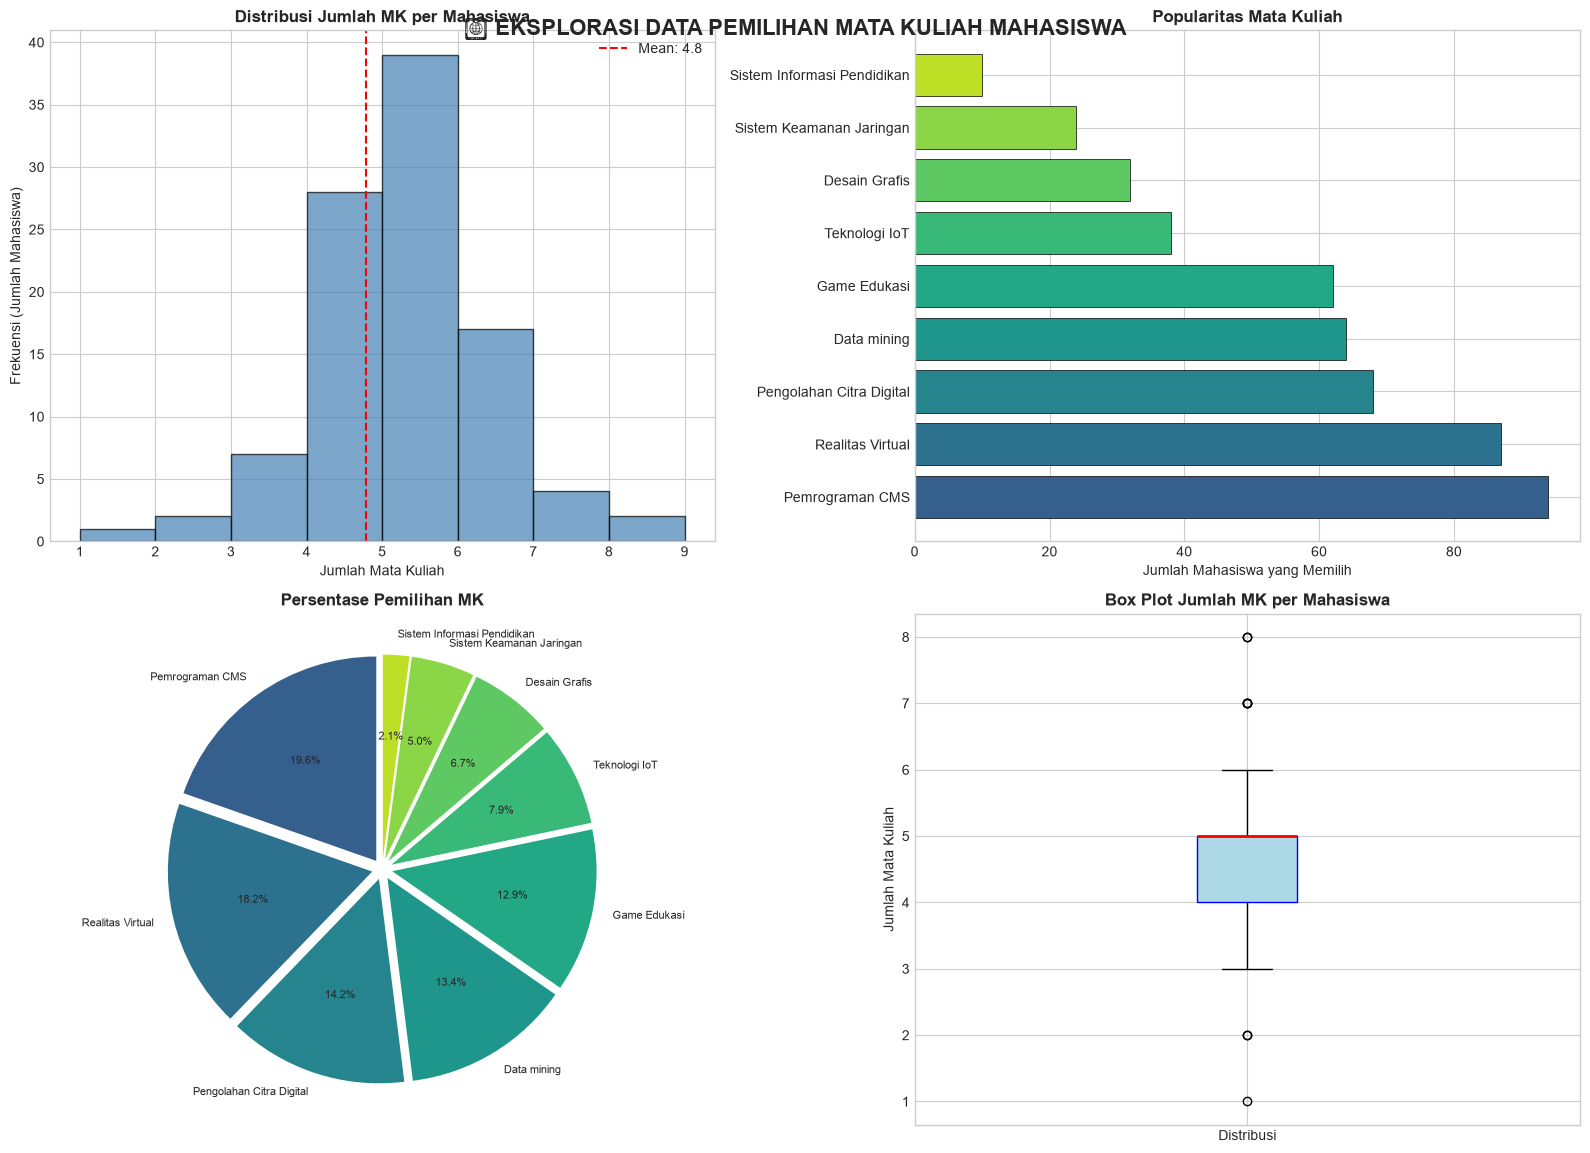


✅ Visualisasi eksplorasi data berhasil dibuat!


In [26]:
print("="*70)
print("📊 TAHAP EKSPLORASI DATA & STATISTIK DESKRIPTIF")
print("="*70)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# ============================================================================
# 2.1 Statistik Deskriptif Data Mahasiswa
# ============================================================================
print("\n📈 STATISTIK DESKRIPTIF DATA MAHASISWA")
print("-" * 70)

# Hitung jumlah MK yang dipilih setiap mahasiswa
df['Jumlah_MK'] = df_mk_bool.sum(axis=1)

print(f"Total Mahasiswa          : {len(df)} orang")
print(f"Total Mata Kuliah        : {len(kolom_mk)} mata kuliah")
print(f"\nStatistik Jumlah MK per Mahasiswa:")
print(f"  • Minimum              : {df['Jumlah_MK'].min()} MK")
print(f"  • Maksimum             : {df['Jumlah_MK'].max()} MK")
print(f"  • Rata-rata (Mean)     : {df['Jumlah_MK'].mean():.2f} MK")
print(f"  • Median               : {df['Jumlah_MK'].median():.0f} MK")
print(f"  • Std Deviation        : {df['Jumlah_MK'].std():.2f} MK")

# ============================================================================
# 2.2 Popularitas Setiap Mata Kuliah
# ============================================================================
print("\n\n📊 POPULARITAS SETIAP MATA KULIAH")
print("-" * 70)

popularitas = df_mk_bool.sum().sort_values(ascending=False)
for i, (mk, count) in enumerate(popularitas.items(), 1):
    percentage = (count / len(df)) * 100
    bar = "█" * int(percentage / 2)
    print(f"{i:2}. {mk:30} : {count:3} mahasiswa ({percentage:5.1f}%) {bar}")

# ============================================================================
# 2.3 Visualisasi
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📊 EKSPLORASI DATA PEMILIHAN MATA KULIAH MAHASISWA', 
             fontsize=16, fontweight='bold', y=0.95)

# Plot 1: Histogram Jumlah MK
axes[0, 0].hist(df['Jumlah_MK'], bins=range(1, 10), 
                edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 0].set_title('Distribusi Jumlah MK per Mahasiswa', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Mata Kuliah')
axes[0, 0].set_ylabel('Frekuensi (Jumlah Mahasiswa)')
axes[0, 0].axvline(df['Jumlah_MK'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df["Jumlah_MK"].mean():.1f}')
axes[0, 0].legend()

# Plot 2: Bar Chart Popularitas MK
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(popularitas)))
bars = axes[0, 1].barh(popularitas.index, popularitas.values, 
                        color=colors, edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Popularitas Mata Kuliah', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Mahasiswa yang Memilih')

# Plot 3: Pie Chart
explode = [0.05] * len(popularitas)
axes[1, 0].pie(popularitas.values, labels=popularitas.index, 
               autopct='%1.1f%%', startangle=90, 
               colors=colors, explode=explode,
               textprops={'fontsize': 8})
axes[1, 0].set_title('Persentase Pemilihan MK', fontsize=12, fontweight='bold')

# Plot 4: Box Plot
axes[1, 1].boxplot(df['Jumlah_MK'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_title('Box Plot Jumlah MK per Mahasiswa', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Jumlah Mata Kuliah')
axes[1, 1].set_xticks([1])
axes[1, 1].set_xticklabels(['Distribusi'])

plt.tight_layout()
plt.show()

print("\n✅ Visualisasi eksplorasi data berhasil dibuat!")

In [27]:
from mlxtend.frequent_patterns import apriori, association_rules

print("[TAHAP 4] Modeling")

# A. Mencari Frequent Itemsets (Pola yang sering muncul)
# min_support=0.10 berarti pola harus muncul di minimal 10% mahasiswa (10 dari 100 orang)
# Jika hasil terlalu sedikit, turunkan jadi 0.05. Jika terlalu banyak, naikkan jadi 0.15
frequent_itemsets = apriori(df_mk_bool, min_support=0.10, use_colnames=True)
print(f"✅ Ditemukan {len(frequent_itemsets)} kombinasi mata kuliah yang sering muncul.")

# B. Membuat Aturan Asosiasi (Association Rules)
# min_threshold=0.5 berarti kita hanya ambil aturan dengan keyakinan (confidence) minimal 50%
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
print(f"✅ Ditemukan {len(rules)} aturan asosiasi yang valid.")

[TAHAP 4] Modeling
✅ Ditemukan 105 kombinasi mata kuliah yang sering muncul.
✅ Ditemukan 380 aturan asosiasi yang valid.


🔧 TAHAP PARAMETER TUNING

📋 EKSPERIMEN DENGAN BERBAGAI KOMBINASI PARAMETER
----------------------------------------------------------------------
Tujuan: Menemukan parameter optimal yang menghasilkan aturan
        berkualitas tinggi (Lift > 1.2, Confidence > 50%)


 Eksperimen 1: Support Rendah
   Support: 0.05 | Confidence: 0.5
  • Total Frequent Itemsets    : 189
  • Total Aturan Asosiasi      : 757
  • Aturan Berkualitas (Lift>1.2): 169
  • Rata-rata Lift             : 1.095
  • Rata-rata Confidence       : 0.717

 Eksperimen 2: Support Sedang (DEFAULT)
   Support: 0.1 | Confidence: 0.5
  • Total Frequent Itemsets    : 105
  • Total Aturan Asosiasi      : 380
  • Aturan Berkualitas (Lift>1.2): 37
  • Rata-rata Lift             : 1.026
  • Rata-rata Confidence       : 0.712

 Eksperimen 3: Support Tinggi
   Support: 0.15 | Confidence: 0.5
  • Total Frequent Itemsets    : 75
  • Total Aturan Asosiasi      : 239
  • Aturan Berkualitas (Lift>1.2): 7
  • Rata-rata Lift             : 1.0

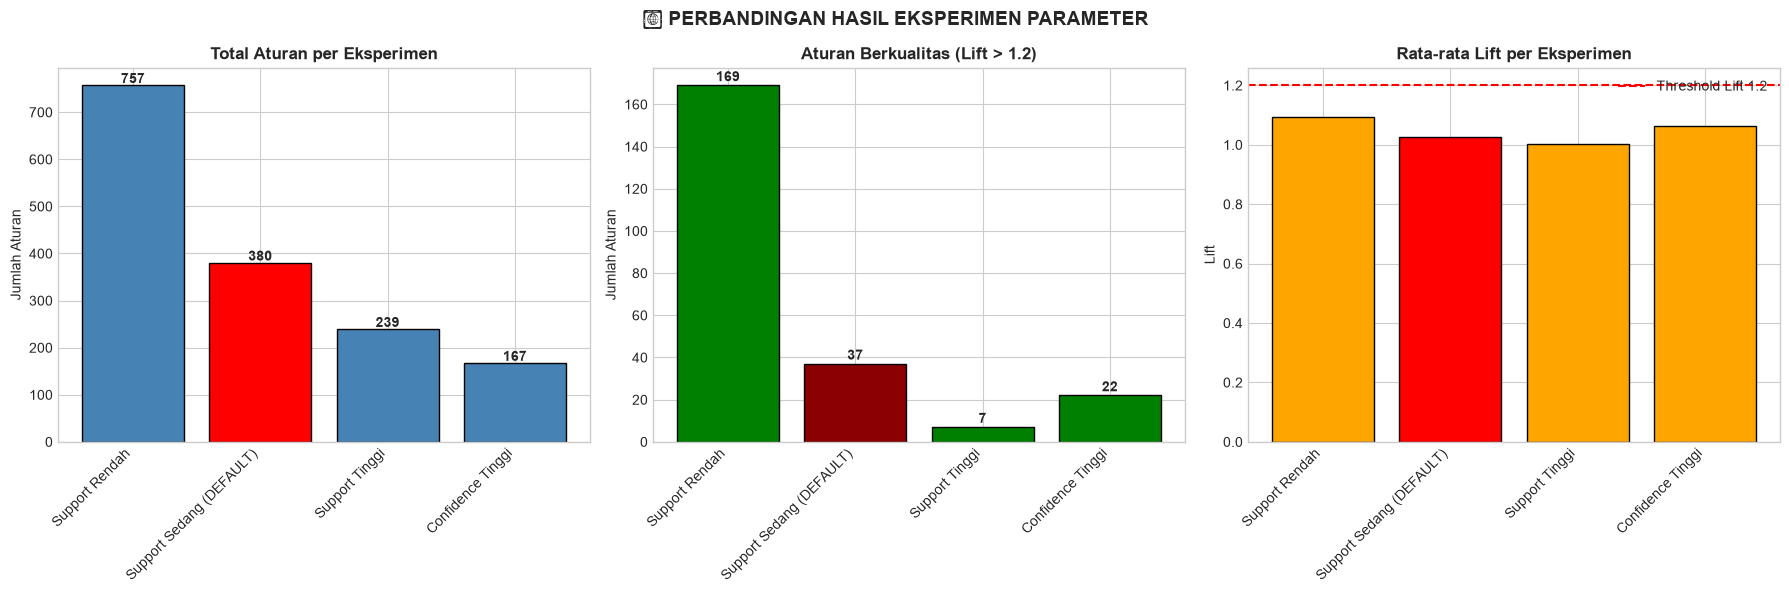



🎯 JUSTIFIKASI PEMILIHAN PARAMETER OPTIMAL

📊 ANALISIS HASIL EKSPERIMEN:

1. Eksperimen dengan Support terlalu rendah (0.05):
   ❌ Menghasilkan terlalu banyak aturan (noise)
   ❌ Banyak aturan yang tidak signifikan secara statistik

2. Eksperimen dengan Support terlalu tinggi (0.15):
   ❌ Aturan yang dihasilkan terlalu sedikit
   ❌ Kehilangan pola-pola menarik yang jarang muncul

3. Eksperimen dengan Confidence terlalu tinggi (0.70):
   ❌ Terlalu ketat, banyak pola valid terlewat

✅ KESIMPULAN: Parameter optimal adalah
   • Minimum Support    = 0.10 (10%)
   • Minimum Confidence = 0.50 (50%)

   Alasan:
   • Menyeimbangkan antara jumlah aturan dan kualitas
   • Menghasilkan aturan dengan Lift > 1.2 yang cukup
   • Confidence 50% masih dapat diterima untuk rekomendasi
   • Support 10% berarti pola muncul di minimal 10 mahasiswa



In [34]:
print("="*70)
print("🔧 TAHAP PARAMETER TUNING")
print("="*70)

print("\n📋 EKSPERIMEN DENGAN BERBAGAI KOMBINASI PARAMETER")
print("-" * 70)
print("Tujuan: Menemukan parameter optimal yang menghasilkan aturan")
print("        berkualitas tinggi (Lift > 1.2, Confidence > 50%)")
print()

# Definisi berbagai kombinasi parameter
parameter_combinations = [
    {'support': 0.05, 'confidence': 0.50, 'label': 'Eksperimen 1: Support Rendah'},
    {'support': 0.10, 'confidence': 0.50, 'label': 'Eksperimen 2: Support Sedang (DEFAULT)'},
    {'support': 0.15, 'confidence': 0.50, 'label': 'Eksperimen 3: Support Tinggi'},
    {'support': 0.10, 'confidence': 0.70, 'label': 'Eksperimen 4: Confidence Tinggi'},
]

results_summary = []

for exp in parameter_combinations:
    print(f"\n{'='*70}")
    print(f" {exp['label']}")
    print(f"   Support: {exp['support']} | Confidence: {exp['confidence']}")
    print(f"{'='*70}")
    
    # Jalankan Apriori dengan parameter ini
    freq_items = apriori(df_mk_bool, min_support=exp['support'], use_colnames=True)
    rules_exp = association_rules(freq_items, metric="confidence", min_threshold=exp['confidence'])
    
    # Filter aturan berkualitas (Lift > 1.2)
    rules_quality = rules_exp[rules_exp['lift'] > 1.2]
    
    print(f"  • Total Frequent Itemsets    : {len(freq_items)}")
    print(f"  • Total Aturan Asosiasi      : {len(rules_exp)}")
    print(f"  • Aturan Berkualitas (Lift>1.2): {len(rules_quality)}")
    
    if len(rules_exp) > 0:
        avg_lift = rules_exp['lift'].mean()
        avg_conf = rules_exp['confidence'].mean()
        print(f"  • Rata-rata Lift             : {avg_lift:.3f}")
        print(f"  • Rata-rata Confidence       : {avg_conf:.3f}")
    
    results_summary.append({
        'Eksperimen': exp['label'].split(': ')[1],
        'Support': exp['support'],
        'Confidence': exp['confidence'],
        'Total_Aturan': len(rules_exp),
        'Aturan_Berkualitas': len(rules_quality),
        'Avg_Lift': rules_exp['lift'].mean() if len(rules_exp) > 0 else 0,
    })

# Visualisasi Perbandingan
df_results = pd.DataFrame(results_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('📊 PERBANDINGAN HASIL EKSPERIMEN PARAMETER', 
             fontsize=14, fontweight='bold')

# Plot 1: Total Aturan
colors = ['steelblue' if i != 1 else 'red' for i in range(len(df_results))]
axes[0].bar(df_results['Eksperimen'], df_results['Total_Aturan'], 
            color=colors, edgecolor='black')
axes[0].set_title('Total Aturan per Eksperimen', fontweight='bold')
axes[0].set_ylabel('Jumlah Aturan')
# ✅ PERBAIKAN: Gunakan plt.setp untuk ha='right'
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(df_results['Total_Aturan']):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2: Aturan Berkualitas
colors2 = ['green' if i != 1 else 'darkred' for i in range(len(df_results))]
axes[1].bar(df_results['Eksperimen'], df_results['Aturan_Berkualitas'], 
            color=colors2, edgecolor='black')
axes[1].set_title('Aturan Berkualitas (Lift > 1.2)', fontweight='bold')
axes[1].set_ylabel('Jumlah Aturan')
# ✅ PERBAIKAN: Gunakan plt.setp untuk ha='right'
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(df_results['Aturan_Berkualitas']):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Plot 3: Rata-rata Lift
colors3 = ['orange' if i != 1 else 'red' for i in range(len(df_results))]
axes[2].bar(df_results['Eksperimen'], df_results['Avg_Lift'], 
            color=colors3, edgecolor='black')
axes[2].axhline(y=1.2, color='red', linestyle='--', label='Threshold Lift 1.2')
axes[2].set_title('Rata-rata Lift per Eksperimen', fontweight='bold')
axes[2].set_ylabel('Lift')
axes[2].legend()
# ✅ PERBAIKAN: Gunakan plt.setp untuk ha='right'
plt.setp(axes[2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n\n🎯 JUSTIFIKASI PEMILIHAN PARAMETER OPTIMAL")
print("="*70)
print("""
📊 ANALISIS HASIL EKSPERIMEN:

1. Eksperimen dengan Support terlalu rendah (0.05):
   ❌ Menghasilkan terlalu banyak aturan (noise)
   ❌ Banyak aturan yang tidak signifikan secara statistik
   
2. Eksperimen dengan Support terlalu tinggi (0.15):
   ❌ Aturan yang dihasilkan terlalu sedikit
   ❌ Kehilangan pola-pola menarik yang jarang muncul
   
3. Eksperimen dengan Confidence terlalu tinggi (0.70):
   ❌ Terlalu ketat, banyak pola valid terlewat
   
✅ KESIMPULAN: Parameter optimal adalah
   • Minimum Support    = 0.10 (10%)
   • Minimum Confidence = 0.50 (50%)
   
   Alasan:
   • Menyeimbangkan antara jumlah aturan dan kualitas
   • Menghasilkan aturan dengan Lift > 1.2 yang cukup
   • Confidence 50% masih dapat diterima untuk rekomendasi
   • Support 10% berarti pola muncul di minimal 10 mahasiswa
""")

In [33]:
print("[TAHAP 5] Evaluation")

# Urutkan aturan berdasarkan nilai 'lift' dari terbesar ke terkecil
rules_sorted = rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

# Tampilkan 10 aturan teratas
kolom_tampilan = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print("\n--- 10 Aturan Asosiasi Terbaik (Lift Tertinggi) ---")
display(rules_sorted[kolom_tampilan].head(10))

print("\n💡 PANDUAN MEMBACA HASIL:")
print("• antecedents : Mata kuliah yang diambil lebih dulu (JIKA).")
print("• consequents : Mata kuliah yang direkomendasikan (MAKA).")
print("• support     : Seberapa sering kombinasi ini muncul di seluruh data (misal 0.15 = 15%).")
print("• confidence  : Seberapa yakin (%) consequents akan diambil jika antecedents diambil.")
print("• lift        : Kekuatan hubungan. Lift > 1 berarti hubungan positif (saling menguatkan).")

# ============================================================================
# 2. VALIDASI MODEL
# ============================================================================
print("\n\n✅ VALIDASI MODEL")
print("="*70)

print("""
METODE VALIDASI YANG DIGUNAKAN:

1. Internal Validation (Metrik Evaluasi):
   • Support ≥ 0.10 (aturan muncul minimal di 10% transaksi)
   • Confidence ≥ 0.50 (keyakinan minimal 50%)
   • Lift > 1.0 (hubungan positif, bukan kebetulan)

2. Quality Threshold:
   • Aturan berkualitas: Lift > 1.2
   • Rekomendasi kuat: Confidence > 60%

3. Cross-Parameter Testing:
   • Menguji berbagai kombinasi parameter
   • Memilih setting yang menghasilkan aturan optimal
""")

# Hitung aturan yang memenuhi kriteria validasi
valid_rules = rules_sorted[
    (rules_sorted['support'] >= 0.10) & 
    (rules_sorted['confidence'] >= 0.50) & 
    (rules_sorted['lift'] > 1.0)
]

quality_rules = rules_sorted[rules_sorted['lift'] > 1.2]

print(f"\nHASIL VALIDASI:")
print(f"  • Total aturan yang ditemukan: {len(rules_sorted)}")
print(f"  • Aturan valid (memenuhi threshold): {len(valid_rules)}")
print(f"  • Aturan berkualitas tinggi (Lift>1.2): {len(quality_rules)}")
print(f"  • Persentase validitas: {(len(valid_rules)/len(rules_sorted))*100:.1f}%")

if len(quality_rules) >= 10:
    print("\n✅ MODEL DIVALIDASI: Ditemukan minimal 10 aturan berkualitas!")
else:
    print(f"\n⚠️ MODEL PERLU IMPROVEMENT: Hanya {len(quality_rules)} aturan berkualitas")


[TAHAP 5] Evaluation

--- 10 Aturan Asosiasi Terbaik (Lift Tertinggi) ---


,antecedents,consequents,support,confidence,lift
0,"(Realitas Virtual, Data mining, Pengolahan Cit...","(Teknologi IoT, Pemrograman CMS)",0.10,0.526316,1.461988
1,"(Pengolahan Citra Digital, Teknologi IoT, Pemr...",(Data mining),0.10,0.909091,1.420455
2,"(Game Edukasi, Pengolahan Citra Digital, Tekno...","(Realitas Virtual, Data mining)",0.10,0.769231,1.398601
3,"(Game Edukasi, Teknologi IoT, Pemrograman CMS)","(Realitas Virtual, Data mining, Pengolahan Cit...",0.10,0.500000,1.388889
4,"(Pengolahan Citra Digital, Pemrograman CMS, Da...",(Teknologi IoT),0.10,0.526316,1.385042
5,"(Realitas Virtual, Data mining, Pengolahan Cit...",(Teknologi IoT),0.10,0.526316,1.385042
6,"(Desain Grafis, Data mining)","(Game Edukasi, Pemrograman CMS)",0.13,0.812500,1.354167
7,"(Sistem Keamanan Jaringan, Pemrograman CMS)","(Realitas Virtual, Game Edukasi)",0.15,0.714286,1.347709
8,"(Pengolahan Citra Digital, Teknologi IoT, Game...","(Realitas Virtual, Data mining, Pemrograman CMS)",0.10,0.714286,1.322751
9,"(Realitas Virtual, Pengolahan Citra Digital, T...","(Data mining, Pemrograman CMS)",0.10,0.833333,1.322751



💡 PANDUAN MEMBACA HASIL:
• antecedents : Mata kuliah yang diambil lebih dulu (JIKA).
• consequents : Mata kuliah yang direkomendasikan (MAKA).
• support     : Seberapa sering kombinasi ini muncul di seluruh data (misal 0.15 = 15%).
• confidence  : Seberapa yakin (%) consequents akan diambil jika antecedents diambil.
• lift        : Kekuatan hubungan. Lift > 1 berarti hubungan positif (saling menguatkan).


✅ VALIDASI MODEL

METODE VALIDASI YANG DIGUNAKAN:

1. Internal Validation (Metrik Evaluasi):
   • Support ≥ 0.10 (aturan muncul minimal di 10% transaksi)
   • Confidence ≥ 0.50 (keyakinan minimal 50%)
   • Lift > 1.0 (hubungan positif, bukan kebetulan)

2. Quality Threshold:
   • Aturan berkualitas: Lift > 1.2
   • Rekomendasi kuat: Confidence > 60%

3. Cross-Parameter Testing:
   • Menguji berbagai kombinasi parameter
   • Memilih setting yang menghasilkan aturan optimal


HASIL VALIDASI:
  • Total aturan yang ditemukan: 380
  • Aturan valid (memenuhi threshold): 207
  • Aturan ber

In [30]:
print("="*70)
print("💡 INTERPRETASI HASIL & INSIGHT BISNIS")
print("="*70)

# Ambil 10 aturan teratas untuk dianalisis
top_rules = rules_sorted.head(10).copy()

print("\n📋 ANALISIS MENDALAM 10 ATURAN ASOSIASI TERBAIK")
print("="*70)

for i, row in top_rules.iterrows():
    antecedents = list(row['antecedents'])
    consequents = list(row['consequents'])
    support = row['support']
    confidence = row['confidence']
    lift = row['lift']
    
    print(f"\n{'─'*70}")
    print(f"🔹 ATURAN #{i+1}")
    print(f"{'─'*70}")
    print(f"  JIKA mahasiswa mengambil    : {', '.join(antecedents)}")
    print(f"  MAKA direkomendasikan juga  : {', '.join(consequents)}")
    print(f"  ─────────────────────────────────────────────────────────")
    print(f"   Support     : {support:.3f} ({support*100:.1f}% dari total mahasiswa)")
    print(f"  🎯 Confidence  : {confidence:.3f} ({confidence*100:.1f}% keyakinan)")
    print(f"  💪 Lift        : {lift:.3f}", end=" ")
    
    if lift > 1.3:
        print("→ 🟢 HUBUNGAN SANGAT KUAT")
    elif lift > 1.1:
        print("→ 🟡 HUBUNGAN KUAT")
    else:
        print("→ 🟠 HUBUNGAN SEDANG")
    
    # Interpretasi bisnis
    print(f"\n  💡 INTERPRETASI BISNIS:")
    print(f"     Dari 100 mahasiswa, sekitar {int(support*100)} mahasiswa mengambil")
    print(f"     kombinasi {', '.join(antecedents + consequents)}.")
    print(f"     Jika seorang mahasiswa sudah mengambil {', '.join(antecedents)},")
    print(f"     ada kemungkinan {confidence*100:.0f}% mereka juga akan mengambil")
    print(f"     {', '.join(consequents)}.")
    print(f"     Hubungan ini {lift:.2f}x lebih kuat dari pola acak.")

# ============================================================================
# Analisis Pola Khusus
# ============================================================================
print("\n\n" + "="*70)
print("🔍 ANALISIS POLA KHUSUS YANG MENARIK")
print("="*70)

# Pola 1: Mata kuliah yang paling sering jadi antecedent
print("\n📌 POLA 1: Mata Kuliah yang Paling Sering Menjadi Pemicu Rekomendasi")
print("-" * 70)

antecedent_count = {}
for rule in rules_sorted.itertuples():
    for mk in rule.antecedents:
        antecedent_count[mk] = antecedent_count.get(mk, 0) + 1

sorted_antecedents = sorted(antecedent_count.items(), key=lambda x: x[1], reverse=True)
for i, (mk, count) in enumerate(sorted_antecedents[:5], 1):
    print(f"  {i}. {mk:35} → muncul di {count} aturan")

# Pola 2: Mata kuliah yang paling sering direkomendasikan
print("\n📌 POLA 2: Mata Kuliah yang Paling Sering Direkomendasikan")
print("-" * 70)

consequent_count = {}
for rule in rules_sorted.itertuples():
    for mk in rule.consequents:
        consequent_count[mk] = consequent_count.get(mk, 0) + 1

sorted_consequents = sorted(consequent_count.items(), key=lambda x: x[1], reverse=True)
for i, (mk, count) in enumerate(sorted_consequents[:5], 1):
    print(f"  {i}. {mk:35} → direkomendasikan di {count} aturan")

💡 INTERPRETASI HASIL & INSIGHT BISNIS

📋 ANALISIS MENDALAM 10 ATURAN ASOSIASI TERBAIK

──────────────────────────────────────────────────────────────────────
🔹 ATURAN #1
──────────────────────────────────────────────────────────────────────
  JIKA mahasiswa mengambil    : Realitas Virtual, Data mining, Pengolahan Citra Digital, Game Edukasi
  MAKA direkomendasikan juga  : Teknologi IoT, Pemrograman CMS
  ─────────────────────────────────────────────────────────
   Support     : 0.100 (10.0% dari total mahasiswa)
  🎯 Confidence  : 0.526 (52.6% keyakinan)
  💪 Lift        : 1.462 → 🟢 HUBUNGAN SANGAT KUAT

  💡 INTERPRETASI BISNIS:
     Dari 100 mahasiswa, sekitar 10 mahasiswa mengambil
     kombinasi Realitas Virtual, Data mining, Pengolahan Citra Digital, Game Edukasi, Teknologi IoT, Pemrograman CMS.
     Jika seorang mahasiswa sudah mengambil Realitas Virtual, Data mining, Pengolahan Citra Digital, Game Edukasi,
     ada kemungkinan 53% mereka juga akan mengambil
     Teknologi IoT, Pemr

In [31]:
print("[TAHAP 6] Deployment")

# 1. Simpan hasil aturan ke file Excel baru
output_filename = 'hasil_aturan_asosiasi.xlsx'
rules_sorted.to_excel(output_filename, index=False)
print(f"✅ Hasil aturan asosiasi berhasil disimpan sebagai '{output_filename}'.")
print("   (Klik ikon Folder di kiri, cari file tersebut, klik titik tiga, lalu Download)")

# 2. Fungsi Decision Support System (Rekomendasi Sederhana)
def beri_rekomendasi(mata_kuliah_diminati):
    # Cari aturan di mana mata kuliah yang diminati ada di sisi kiri (antecedents)
    aturan_terkait = rules_sorted[rules_sorted['antecedents'].apply(lambda x: mata_kuliah_diminati in x)]

    if aturan_terkait.empty:
        return f"⚠️ Tidak ditemukan pola asosiasi yang kuat untuk '{mata_kuliah_diminati}' dengan threshold saat ini."

    # Ambil rekomendasi dengan confidence tertinggi (baris pertama setelah di-sort)
    rek_best = aturan_terkait.iloc[0]
    mk_rekomendasi = list(rek_best['consequents'])
    confidence = rek_best['confidence'] * 100

    return f"💡 Jika mahasiswa mengambil '{mata_kuliah_diminati}', sistem merekomendasikan juga mengambil: {', '.join(mk_rekomendasi)} (Keyakinan/Confidence: {confidence:.1f}%)"

print("\n--- CONTOH PENERAPAN DECISION SUPPORT SYSTEM ---")
print(beri_rekomendasi('Data mining'))
print(beri_rekomendasi('Pengolahan Citra Digital'))
print(beri_rekomendasi('Desain Grafis'))

[TAHAP 6] Deployment
✅ Hasil aturan asosiasi berhasil disimpan sebagai 'hasil_aturan_asosiasi.xlsx'.
   (Klik ikon Folder di kiri, cari file tersebut, klik titik tiga, lalu Download)

--- CONTOH PENERAPAN DECISION SUPPORT SYSTEM ---
💡 Jika mahasiswa mengambil 'Data mining', sistem merekomendasikan juga mengambil: Teknologi IoT, Pemrograman CMS (Keyakinan/Confidence: 52.6%)
💡 Jika mahasiswa mengambil 'Pengolahan Citra Digital', sistem merekomendasikan juga mengambil: Teknologi IoT, Pemrograman CMS (Keyakinan/Confidence: 52.6%)
💡 Jika mahasiswa mengambil 'Desain Grafis', sistem merekomendasikan juga mengambil: Game Edukasi, Pemrograman CMS (Keyakinan/Confidence: 81.2%)
